In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

/tmp/ipykernel_47/1102668386.py:1: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/kaggle/input/sentiment-analysis-dataset/training.1600000.processed.noemoticon.csv',


['polarity of tweet\xa0' '0' 0 4]
['0' 4]
Dataset shape: (59999, 6)

First few rows:
  polarity          id                          date     query           user  \
0        0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY  scotthamilton   
1        0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY       mattycus   
2        0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY        ElleCTF   
3        0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY         Karoli   
4        0  1467811372  Mon Apr 06 22:20:00 PDT 2009  NO_QUERY       joy_wolf   

                                                text  
0  is upset that he can't update his Facebook by ...  
1  @Kenichan I dived many times for the ball. Man...  
2    my whole body feels itchy and like its on fire   
3  @nationwideclass no, it's not behaving at all....  
4                      @Kwesidei not the whole crew   

Sentiment distribution:
polarity
4    30000
0    29999
Name: count, dtype: int64
  polarity      

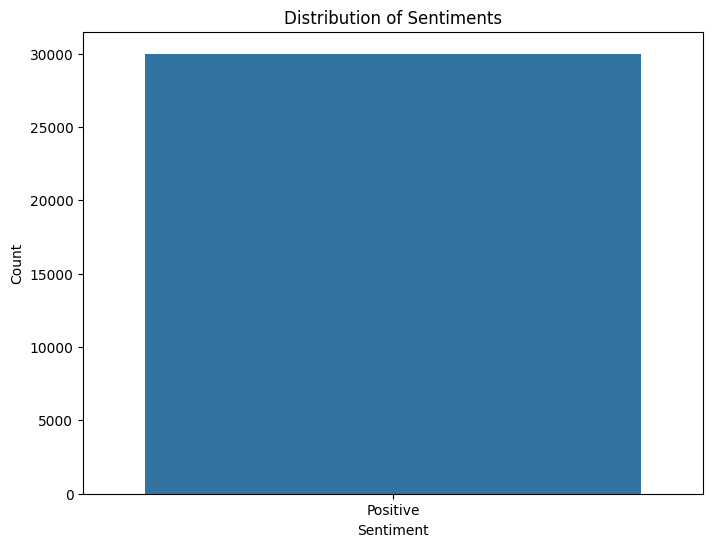

In [15]:
df = pd.read_csv('/kaggle/input/sentiment-analysis-dataset/training.1600000.processed.noemoticon.csv', 
                 header=None,
                 names=['polarity', 'id', 'date', 'query', 'user', 'text'],
                 encoding='latin1')
print(df['polarity'].unique())
df_first_3000 = df.iloc[1:30000]
df_last_3000 = df.iloc[-30000:]
df = pd.concat([df_first_3000, df_last_3000], ignore_index=True)

print(df['polarity'].unique())
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\nSentiment distribution:")
print(df['polarity'].value_counts())

sentiment_map = {0: 'Negative', 2: 'Neutral', 4: 'Positive'}
df['sentiment'] = df['polarity'].map(sentiment_map)
print(df.head())

plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df)
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [16]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.lower()
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess_text)
df['polarity'] = df['polarity'].astype(int)
df['polarity'] = df['polarity'].map({0: 0, 4: 1})

print("\nSample of original and cleaned text:")
for i in range(3):
    print(f"Original: {df.iloc[i]['text']}")
    print(f"Cleaned: {df.iloc[i]['clean_text']}")
    print()


Sample of original and cleaned text:
Original: is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!
Cleaned: upset cant update facebook texting might cry result school today also blah

Original: @Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds
Cleaned: dived many time ball managed save rest go bound

Original: my whole body feels itchy and like its on fire 
Cleaned: whole body feel itchy like fire



In [17]:
max_length = 100 
embedding_dim = 128
test_size = 0.2   
random_state = 42  
X = df['clean_text']
y = df['polarity']

all_words = ' '.join(X).split()
unique_words = set(all_words)
vocab_size = int(len(unique_words))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state, stratify=y
)

tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

num_classes = len(df['polarity'].unique())
print(num_classes)
y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test_one_hot = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)

print(f"Training data shape: {X_train_pad.shape}")
print(f"Testing data shape: {X_test_pad.shape}")

2
Training data shape: (47999, 100)
Testing data shape: (12000, 100)


In [20]:
model = Sequential([
    Embedding(input_dim=vocab_size,output_dim=embedding_dim,input_length=max_length),
    Bidirectional(LSTM(128, return_sequences=True, dropout=0.3)),
    Bidirectional(LSTM(64, dropout=0.3)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)
history = model.fit(
    X_train_pad, y_train_one_hot,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.6513 - loss: 0.5996 - val_accuracy: 0.7623 - val_loss: 0.5032
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.8349 - loss: 0.3789 - val_accuracy: 0.7550 - val_loss: 0.5161
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.8822 - loss: 0.2837 - val_accuracy: 0.7492 - val_loss: 0.5749
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.9162 - loss: 0.2106 - val_accuracy: 0.7444 - val_loss: 0.6915


375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7672 - loss: 0.4920
Test Loss: 0.4894
Test Accuracy: 0.7693
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.80      0.77      6000
    Positive       0.78      0.74      0.76      6000

    accuracy                           0.77     12000
   macro avg       0.77      0.77      0.77     12000
weighted avg       0.77      0.77      0.77     12000



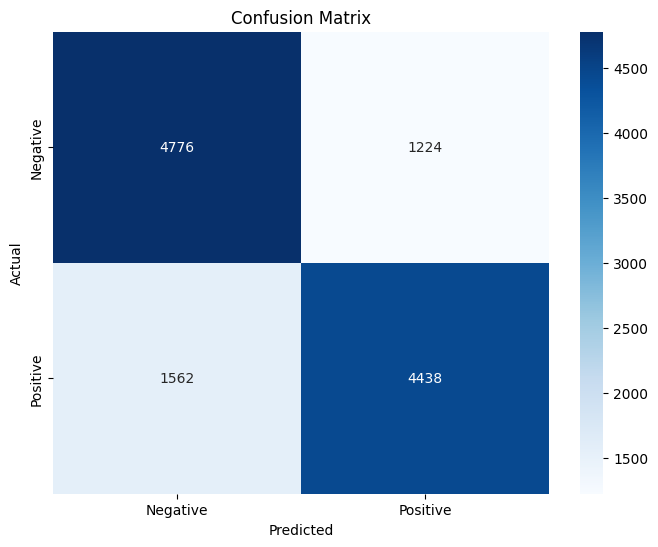

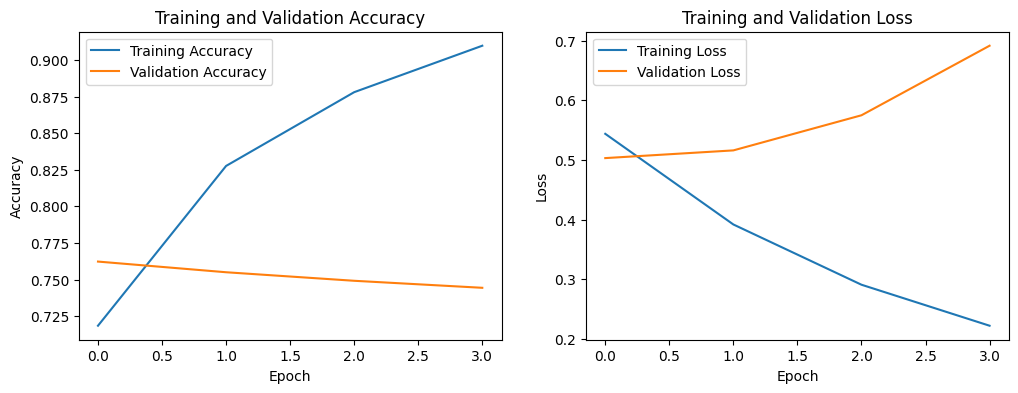

In [23]:
loss, accuracy = model.evaluate(X_test_pad, y_test_one_hot)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

y_pred = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_one_hot, axis=1)

print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=['Negative', 'Positive']))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [35]:
def predict_sentiment(text):
    clean_text = preprocess_text(text)
    sequence = tokenizer.texts_to_sequences([clean_text])
    padded_sequence = pad_sequences(sequence, maxlen=max_length, padding='post', truncating='post')
    prediction = model.predict(padded_sequence)
    predicted_class = np.argmax(prediction, axis=1)[0]
    sentiment_map = {0: 'Negative', 1: 'Positive'}
    return sentiment_map[predicted_class]

test_texts = [
    "I love this new phone, it's amazing!",
    "The movie was terrible, I almost fell asleep.",
    "The weather is okay today, nothing special."
]

for text in test_texts:
    sentiment = predict_sentiment(text)
    print(f"Text: '{text}'\nPredicted Sentiment: {sentiment}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Text: 'I love this new phone, it's amazing!'
Predicted Sentiment: Positive

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Text: 'The movie was terrible, I almost fell asleep.'
Predicted Sentiment: Negative

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Text: 'The weather is okay today, nothing special.'
Predicted Sentiment: Negative



In [29]:
model.save('sentiment_analysis_model.keras')
import pickle
with open('tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("Model and tokenizer saved successfully!")

Model and tokenizer saved successfully!


In [34]:
text="Hi"
clean_text = preprocess_text(text)
sequence = tokenizer.texts_to_sequences([clean_text])
padded_sequence = pad_sequences(sequence, maxlen=max_length, padding='post', truncating='post')
prediction = model.predict(padded_sequence)
predicted_class = np.argmax(prediction, axis=1)[0]
sentiment_map = {0: 'Negative', 1: 'Positive'}
sentiment_map[predicted_class]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


'Positive'